[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/WCC-Engineering/wcc-engineering-engr-240-spring-2026-pa1-introduction-to-python-numpy-and-data-visualization-ENGR240/blob/main/problem3_heat_transfer.ipynb)

# Problem 3: Heat Transfer Analysis with NumPy and Matplotlib

## Description
You are studying heat transfer through a wall as temperatures change throughout the day. Use NumPy to generate and analyze temperature data and Matplotlib to visualize the heat flow.

## Tasks
1. Create a time array from 0 to 24 hours with 1-hour intervals using NumPy
2. Generate temperature arrays for:
   - Outside temperatures following a sinusoidal pattern: T_out = 20 + 10*sin(π*t/12), where t is time in hours
   - Inside temperatures held constant at 22°C
3. Calculate the temperature difference (ΔT = T_out - T_in) at each time point
4. Calculate heat flow through the wall using: Q = k*A*ΔT/d, where:
   - k = 0.5 W/(m·K) (thermal conductivity)
   - A = 10 m² (wall area)
   - d = 0.2 m (wall thickness)
5. Determine and display as strings:
   - Maximum and minimum heat flow values with their corresponding times
   - Total heat energy over the 24-hour period (simple sum of hourly heat flow values)
   - Times when heat flows inward vs. outward (when ΔT changes sign)
6. Create a properly labeled plot showing:
   - Outside temperature curve
   - Inside temperature (constant) line
   - Heat flow (positive and negative) with different colors for inward and outward flow
   - Appropriate title, axis labels with units, and legend

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Heat transfer parameters
k = 0.5  # thermal conductivity (W/(m·K))
A = 10   # wall area (m²)
d = 0.2  # wall thickness (m)
T_in = 22  # indoor temperature (°C)

## Task 1: Create time array

Create a time array called `time` with values from 0 to 24 hours in 1-hour intervals.

In [7]:
time = np.linspace(0,24,25)

[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24.]


## Task 2: Generate temperature arrays

Create two arrays:
- `T_out` for outside temperatures following the sinusoidal pattern
- `T_in_array` for the constant inside temperature

In [8]:
T_out = (20 + 10*np.sin(np.pi*time/12))
T_in_array = [T_in for hour in time]

[20.         22.58819045 25.         27.07106781 28.66025404 29.65925826
 30.         29.65925826 28.66025404 27.07106781 25.         22.58819045
 20.         17.41180955 15.         12.92893219 11.33974596 10.34074174
 10.         10.34074174 11.33974596 12.92893219 15.         17.41180955
 20.        ]
[22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22]


## Task 3: Calculate temperature difference

Calculate the temperature difference and store it in an array called `delta_T`.

In [9]:
delta_T = T_out - T_in_array

## Task 4: Calculate heat flow

Calculate the heat flow through the wall and store it in an array called `heat_flow`.

In [10]:
heat_flow = k * A * delta_T / d

## Task 5: Analyze heat flow

In [12]:
# a. Find maximum and minimum heat flow
# Create variables for maximum and minimum flow:
# - `max_flow` for the maximum heat flow value
max_flow = np.max(heat_flow)
# - `min_flow` for the minimum heat flow value
min_flow = np.min(heat_flow)
# - `max_time` for the time when maximum flow occurs
max_time = time[np.argmax(heat_flow)]
# - `min_time` for the time when minimum flow occurs
min_time = time[np.argmin(heat_flow)]

In [13]:
# b. Calculate total heat transfer (simple sum of hourly heat flow)
# Create a variable called `total_heat` for the total heat transfer
total_heat = np.sum(heat_flow)

In [22]:
# c. Identify times when heat flows inward vs. outward
# Create the following variables:
# - `inward_flow_mask` - a boolean mask where True indicates inward flow (negative heat flow)
inward_flow_mask = np.array(heat_flow) <= 0
# - `outward_flow_mask` - a boolean mask where True indicates outward flow (positive heat flow)
outward_flow_mask = np.array(heat_flow) > 0
# - `inward_times_string` - a string showing times when flow is inward
inward_times_string = time[inward_flow_mask]
# - `outward_times_string` - a string showing times when flow is outward
outward_times_string = time[outward_flow_mask]

## Task 6: Create visualization

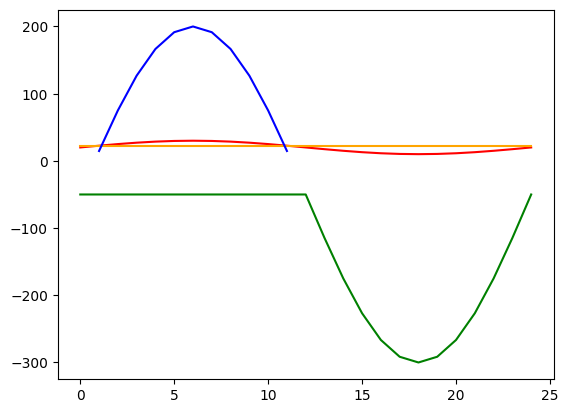

<Figure size 640x480 with 0 Axes>

In [23]:
# Create figure and plot data
"""
Outside temperature curve
Inside temperature (constant) line
Heat flow (positive and negative) with different colors for inward and outward flow
Appropriate title, axis labels with units, and legend
"""
plt.plot(time, T_out, color="red")     #Temperature outside
plt.plot(time, T_in_array, color="orange") #Temperature inside (constant)
plt.plot(inward_times_string, heat_flow[inward_flow_mask], color="green") #Inward heat flow plotted in green
plt.plot(outward_times_string, heat_flow[outward_flow_mask], color="blue") #Outward heat flow plotted in blue


# Add labels, title, legend, and grid
plt.figure()


# Show the plot
plt.tight_layout()
plt.show()